# VMambaCC-Inspired Density-Map Crowd Counting
### ShanghaiTech Dataset | PyTorch | Google Colab

> **Disclaimer:** This is a PyTorch approximation inspired by the VMambaCC paper  
> (Ma et al., ACM MM 2024). The exact VMamba / Selective State Space (SSM)  
> kernel is not publicly released; the VSS block below uses a depthwise-conv  
> approximation that mimics the linear-complexity global-scan behaviour.  
> Architecture components (MHF attention, HS2FPN) follow the paper's design.


## 1 · Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2 · Install & Import Dependencies

In [ ]:
# timm is used only for weight-init utilities; not for VMamba backbone
!pip install timm --quiet


In [ ]:
import os, glob, math, json, time
import numpy as np
import scipy.io
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Using device: cuda


## 3 · Dataset Paths  
*(Adjust `DATA_PATH` to your Drive layout.)*

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech"

TRAIN_A = os.path.join(DATA_PATH, "part_A", "train_data", "images")
TEST_A  = os.path.join(DATA_PATH, "part_A", "test_data",  "images")

print("Dataset root exists :", os.path.exists(DATA_PATH))
print("Train-A images      :", len(glob.glob(os.path.join(TRAIN_A, "*.jpg"))))
print("Test-A  images      :", len(glob.glob(os.path.join(TEST_A,  "*.jpg"))))


Dataset root exists : True
Train-A images      : 300
Test-A  images      : 182


## 4 · Density-Map Generation  

Each annotated point is placed as a Dirac impulse and then convolved with a Gaussian kernel (σ=15 on Part-A). The integral of the density map equals the head count.

In [ ]:
def load_points(mat_path: str) -> np.ndarray:
    """Return (N,2) array of (x,y) annotations from a ShanghaiTech .mat file."""
    mat    = scipy.io.loadmat(mat_path)
    points = mat["image_info"][0][0][0][0][0]   # standard SHT format
    return points.astype(np.float32)


def generate_density_map(image: np.ndarray,
                          points: np.ndarray,
                          sigma: float = 15.0) -> np.ndarray:
    """
    Gaussian-kernel density map.
    Integral of the output ≈ head count.
    Args:
        image  : HxWx3 numpy array (only shape is used).
        points : (N,2) array of (x, y) annotations.
        sigma  : Gaussian kernel bandwidth (pixels).
    Returns:
        density : (H, W) float32 numpy array.
    """
    h, w   = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for p in points:
        x = int(min(w - 1, max(0, round(p[0]))))
        y = int(min(h - 1, max(0, round(p[1]))))
        density[y, x] += 1.0
    density = gaussian_filter(density, sigma=sigma)
    return density


## 5 · Dataset & DataLoader  

`ShanghaiTechDataset` resizes images and density maps to a fixed spatial size so we can batch them.

In [ ]:
IMG_SIZE   = 512          # spatial size fed to the model
PATCH_SIZE = IMG_SIZE     # we use the full resized image (no tiling)
SIGMA      = 15.0         # Gaussian sigma for Part-A


class ShanghaiTechDataset(Dataset):
    """
    ShanghaiTech Part-A / Part-B dataset.
    Returns (image_tensor [3,H,W], density_tensor [1,H,W]).
    The density map is rescaled so that its sum equals the original count.
    """

    def __init__(self,
                 image_folder: str,
                 img_size: int = IMG_SIZE,
                 sigma: float  = SIGMA,
                 augment: bool = False,
                 cache: bool = True):
        self.image_paths = sorted(glob.glob(os.path.join(image_folder, "*.jpg")))
        self.gt_paths    = []
        for img_path in self.image_paths:
            fname    = os.path.basename(img_path)
            mat_name = "GT_" + fname.replace(".jpg", ".mat")
            gt_dir   = os.path.join(os.path.dirname(os.path.dirname(img_path)),
                                    "ground-truth")
            self.gt_paths.append(os.path.join(gt_dir, mat_name))

        self.img_size = img_size
        self.sigma    = sigma
        self.augment  = augment
        self.cache    = cache
        self._cache   = {}

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.image_paths)

    def _load_resized_pair(self, idx):
        if self.cache and idx in self._cache:
            img_resized, den_resized = self._cache[idx]
            return img_resized.copy(), den_resized.copy()

        img_path = self.image_paths[idx]
        gt_path  = self.gt_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        points  = load_points(gt_path)
        density = generate_density_map(img, points, sigma=self.sigma)
        true_count = density.sum()

        img_resized = cv2.resize(img, (self.img_size, self.img_size),
                                 interpolation=cv2.INTER_LINEAR)
        den_resized = cv2.resize(density, (self.img_size, self.img_size),
                                 interpolation=cv2.INTER_LINEAR).astype(np.float32)

        den_sum = den_resized.sum()
        if den_sum > 0:
            den_resized = den_resized * (true_count / den_sum)

        if self.cache:
            self._cache[idx] = (img_resized.copy(), den_resized.copy())

        return img_resized, den_resized

    def __getitem__(self, idx):
        img_resized, den_resized = self._load_resized_pair(idx)

        if self.augment and np.random.rand() > 0.5:
            img_resized = np.fliplr(img_resized).copy()
            den_resized = np.fliplr(den_resized).copy()

        if self.augment and np.random.rand() > 0.5:
            alpha = np.random.uniform(0.85, 1.15)
            beta  = np.random.uniform(-12.0, 12.0)
            img_resized = np.clip(img_resized.astype(np.float32) * alpha + beta,
                                  0, 255).astype(np.uint8)

        img_t = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
        img_t = self.normalize(img_t)

        den_t = torch.from_numpy(den_resized).unsqueeze(0).float()

        return img_t, den_t


In [ ]:
BATCH_SIZE = 4
NUM_WORKERS = 4
PIN_MEMORY = DEVICE == "cuda"

train_base_ds = ShanghaiTechDataset(TRAIN_A, augment=True,  cache=True)
val_base_ds   = ShanghaiTechDataset(TRAIN_A, augment=False, cache=True)
test_ds       = ShanghaiTechDataset(TEST_A,  augment=False, cache=True)

val_len   = max(1, int(0.10 * len(train_base_ds)))
train_len = len(train_base_ds) - val_len
split_gen = torch.Generator().manual_seed(SEED)
indices   = torch.randperm(len(train_base_ds), generator=split_gen).tolist()
train_idx = indices[:train_len]
val_idx   = indices[train_len:]

train_sub = Subset(train_base_ds, train_idx)
val_sub   = Subset(val_base_ds,   val_idx)

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
if NUM_WORKERS > 0:
    loader_kwargs.update(persistent_workers=True, prefetch_factor=4)

train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE,
                          shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_sub,   batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,   batch_size=1,
                          shuffle=False, **loader_kwargs)

print(f"Train / Val / Test : {train_len} / {val_len} / {len(test_ds)}")
print(f"DataLoader workers : {NUM_WORKERS}   pin_memory={PIN_MEMORY}")

imgs, dens = next(iter(train_loader))
print(f"Image batch  : {imgs.shape}   dtype={imgs.dtype}")
print(f"Density batch: {dens.shape}   dtype={dens.dtype}")
print(f"Count range  : {dens.sum(dim=[1,2,3]).numpy()}")


Train / Val / Test : 270 / 30 / 182
DataLoader workers : 4   pin_memory=True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Image batch  : torch.Size([4, 3, 512, 512])   dtype=torch.float32
Density batch: torch.Size([4, 1, 512, 512])   dtype=torch.float32
Count range  : [3137.9995  431.      263.0001 2142.9993]


## 6 - VMambaCC-Inspired Architecture

```
VMamba backbone  ->  HS2FPN decoder  ->  density head
```

### 6.1  VSS Block (Visual State Space - **approximation**)
> **Note:** The VSS block below is an approximation, not the official VMamba selective-scan implementation.  
> It uses depthwise long-range convolution plus channel-mix linear layers as a lightweight stand-in.

### 6.2  MHF Attention (Multi-head High-level Feature)
Channel Enhancement Module (CEM) -> Multi-head Spatial Enhancement Module (MSEM) -> High-level CEM (HCEM)

### 6.3  Wider Backbone/Decoder
The training model uses a wider VMambaCC-inspired setting: dims `(128, 256, 512)`, depths `(2, 3, 6)`, decoder output `128`.

### 6.4  HS2FPN (High-level Semantic Supervised FPN)
Top-down feature pyramid with explicit channel projections before each MHF fusion.

### 6.5  Density Head
Conv -> ReLU -> Conv -> Softplus -> non-negative density map


In [ ]:
# ============================================================================
#  6.1  VSS Block  (VMamba-inspired approximation)
# ============================================================================

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor


class VSSBlock(nn.Module):
    """
    VMamba-inspired VSS approximation.
    This is not the official VMamba selective-scan implementation; it replaces
    selective scan with depthwise convolution plus pointwise mixing.
    """

    def __init__(self, dim: int, d_state: int = 16, expand: int = 2,
                 drop_path: float = 0.0):
        super().__init__()
        inner_dim = dim * expand

        self.norm    = nn.LayerNorm(dim)
        self.proj_in = nn.Linear(dim, inner_dim * 2)

        self.dw_conv = nn.Conv2d(
            inner_dim, inner_dim,
            kernel_size=7, padding=3,
            groups=inner_dim, bias=False
        )

        self.ssm_mix = nn.Sequential(
            nn.Linear(inner_dim, inner_dim),
            nn.SiLU(),
            nn.Linear(inner_dim, dim),
        )

        self.norm_out = nn.LayerNorm(dim)
        self.drop_path = DropPath(drop_path)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        res    = x
        x_flat = x.permute(0, 2, 3, 1).reshape(B, H * W, C)
        x_flat = self.norm(x_flat)

        xz        = self.proj_in(x_flat)
        inner_dim = xz.shape[-1] // 2
        x_val, z  = xz[..., :inner_dim], xz[..., inner_dim:]

        x_val = x_val.reshape(B, H, W, inner_dim).permute(0, 3, 1, 2)
        x_val = self.dw_conv(x_val)
        x_val = x_val.permute(0, 2, 3, 1).reshape(B, H * W, inner_dim)
        x_val = x_val * F.silu(z)

        out = self.ssm_mix(x_val)
        out = self.norm_out(out)
        out = out.reshape(B, H, W, C).permute(0, 3, 1, 2)

        return res + self.drop_path(out)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  6.2  MHF Attention  (Multi-head High-level Feature)
# ══════════════════════════════════════════════════════════════════════════════

class CEM(nn.Module):
    """Channel Enhancement Module — §3.2.1"""
    def __init__(self, dim: int):
        super().__init__()
        self.conv_s = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=False),
            nn.Conv2d(dim, dim, kernel_size=1, bias=False),
        )
    def forward(self, fh: torch.Tensor) -> torch.Tensor:
        fm = F.adaptive_max_pool2d(fh, 1)
        fa = F.adaptive_avg_pool2d(fh, 1)
        w  = torch.sigmoid(self.conv_s(fm) + self.conv_s(fa))
        return fh * w


class MSEM(nn.Module):
    """Multi-head Spatial Enhancement Module — §3.2.2"""
    def __init__(self, dim: int, n_heads: int = 4):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.convs = nn.ModuleList([
            nn.Conv2d(2, 1, kernel_size=3, padding=1, bias=False)
            for _ in range(n_heads)
        ])
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        groups     = x.chunk(self.n_heads, dim=1)
        out_groups = []
        for i, g in enumerate(groups):
            mx   = g.max(dim=1, keepdim=True).values
            avg  = g.mean(dim=1, keepdim=True)
            attn = torch.sigmoid(self.convs[i](torch.cat([mx, avg], dim=1)))
            out_groups.append(g * attn)
        return torch.cat(out_groups, dim=1)


class HCEM(nn.Module):
    """High-level Channel Enhancement Module — §3.2.3"""
    def __init__(self, hi_dim: int, lo_dim: int):
        super().__init__()
        self.conv_s = nn.Sequential(
            nn.Conv2d(hi_dim, hi_dim, 1, bias=False),
            nn.Conv2d(hi_dim, lo_dim, 1, bias=False),
        )
    def forward(self, hi: torch.Tensor, lo: torch.Tensor) -> torch.Tensor:
        fm  = F.adaptive_max_pool2d(hi, 1)
        fa  = F.adaptive_avg_pool2d(hi, 1)
        att = torch.sigmoid(self.conv_s(fm) + self.conv_s(fa))
        att = F.interpolate(att.expand(-1, -1, *hi.shape[-2:]),
                            size=lo.shape[-2:], mode="bilinear", align_corners=False)
        return lo * att


class MHFAttention(nn.Module):
    """Full MHF attention block (§3.2)."""
    def __init__(self, hi_dim: int, lo_dim: int, n_heads: int = 4):
        super().__init__()
        self.cem  = CEM(hi_dim)
        self.msem = MSEM(hi_dim, n_heads=n_heads)
        self.hcem = HCEM(hi_dim, lo_dim)
    def forward(self, fh: torch.Tensor, fl: torch.Tensor) -> torch.Tensor:
        out1 = self.cem(fh)
        out2 = self.msem(out1)
        out4 = self.hcem(out2, fl)
        return out4


In [ ]:
# ============================================================================
#  6.3  VMamba Backbone (3-scale feature extractor)
# ============================================================================

def make_2d_norm(num_channels: int) -> nn.Module:
    for groups in (32, 16, 8, 4, 2, 1):
        if num_channels % groups == 0:
            return nn.GroupNorm(groups, num_channels)
    return nn.GroupNorm(1, num_channels)


class VMambaBackbone(nn.Module):
    """
    Lightweight VMamba-style backbone.
    Produces three feature maps at strides 8, 16, 32 relative to input.
    """

    def __init__(self,
                 in_ch:  int   = 3,
                 dims:   tuple = (96, 192, 384),
                 depths: tuple = (2,  2,   4),
                 drop_path_rate: float = 0.15):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, dims[0], kernel_size=4, stride=4, padding=0),
            make_2d_norm(dims[0]),
            nn.GELU(),
        )

        drop_rates = torch.linspace(0, drop_path_rate, sum(depths)).tolist()
        dp_idx = 0

        self.down1  = nn.Sequential(
            nn.Conv2d(dims[0], dims[0], kernel_size=2, stride=2, padding=0),
            make_2d_norm(dims[0]),
        )
        self.stage1 = nn.Sequential(*[
            VSSBlock(dims[0], drop_path=drop_rates[dp_idx + i])
            for i in range(depths[0])
        ])
        dp_idx += depths[0]

        self.down2  = nn.Sequential(
            nn.Conv2d(dims[0], dims[1], kernel_size=2, stride=2, padding=0),
            make_2d_norm(dims[1]),
        )
        self.stage2 = nn.Sequential(*[
            VSSBlock(dims[1], drop_path=drop_rates[dp_idx + i])
            for i in range(depths[1])
        ])
        dp_idx += depths[1]

        self.down3  = nn.Sequential(
            nn.Conv2d(dims[1], dims[2], kernel_size=2, stride=2, padding=0),
            make_2d_norm(dims[2]),
        )
        self.stage3 = nn.Sequential(*[
            VSSBlock(dims[2], drop_path=drop_rates[dp_idx + i])
            for i in range(depths[2])
        ])

    def forward(self, x: torch.Tensor):
        x  = self.stem(x)
        x  = self.down1(x);  f1 = self.stage1(x)
        x  = self.down2(f1); f2 = self.stage2(x)
        x  = self.down3(f2); f3 = self.stage3(x)
        return f1, f2, f3


In [ ]:
# ============================================================================
#  6.4  HS2FPN Decoder  (High-level Semantic Supervised FPN)
# ============================================================================

class HS2FPN(nn.Module):
    """Feature fusion network (Sec. 3.3, Fig. 2). Top-down path."""

    def __init__(self, dims: tuple = (96, 192, 384), out_dim: int = 96):
        super().__init__()
        d0, d1, d2 = dims

        self.proj_32_to_16 = nn.Conv2d(d2, d1, 1)
        self.lat_16        = nn.Conv2d(d1, d1, 1)
        self.proj_16_to_8  = nn.Conv2d(d1, d0, 1)
        self.lat_8         = nn.Conv2d(d0, d0, 1)

        self.mhf_32_to_16 = MHFAttention(hi_dim=d1, lo_dim=d1, n_heads=4)
        self.mhf_16_to_8  = MHFAttention(hi_dim=d0, lo_dim=d0, n_heads=4)

        self.vss_16 = VSSBlock(d1, drop_path=0.05)
        self.vss_8  = VSSBlock(d0, drop_path=0.05)

        self.proj_out = nn.Sequential(
            nn.Conv2d(d0, out_dim, 1),
            make_2d_norm(out_dim),
            nn.GELU(),
            nn.Dropout2d(p=0.10),
        )

    def forward(self, f1, f2, f3):
        f3_proj = self.proj_32_to_16(f3)
        f3_up   = F.interpolate(f3_proj, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        f2_lat  = self.lat_16(f2)
        f2_mhf  = self.mhf_32_to_16(f3_up, f2_lat)
        fuse16  = self.vss_16(f2_mhf + f3_up)

        fuse16_proj = self.proj_16_to_8(fuse16)
        fuse16_up   = F.interpolate(fuse16_proj, size=f1.shape[-2:], mode="bilinear", align_corners=False)
        f1_lat      = self.lat_8(f1)
        f1_mhf      = self.mhf_16_to_8(fuse16_up, f1_lat)
        fuse8       = self.vss_8(f1_mhf + fuse16_up)

        return self.proj_out(fuse8)


In [ ]:
# ============================================================================
#  6.5  Density Head
# ============================================================================

class DensityHead(nn.Module):
    """1x1-conv regression head -> 1-channel non-negative density map."""
    def __init__(self, in_dim: int = 96, img_size: int = IMG_SIZE,
                 init_count: float = 100.0):
        super().__init__()
        hidden_dim = in_dim // 2
        self.conv = nn.Sequential(
            nn.Conv2d(in_dim, hidden_dim, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.10),
        )
        self.out_conv = nn.Conv2d(hidden_dim, 1, 1)
        self.activation = nn.Softplus()

        init_density = max(float(init_count), 1.0) / float(img_size * img_size)
        init_bias = math.log(math.expm1(init_density))
        nn.init.normal_(self.out_conv.weight, mean=0.0, std=1e-3)
        nn.init.constant_(self.out_conv.bias, init_bias)

    def forward(self, x: torch.Tensor, target_size: tuple) -> torch.Tensor:
        out = self.conv(x)
        out = self.activation(self.out_conv(out))
        out = F.interpolate(out, size=target_size, mode="bilinear", align_corners=False)
        return out


In [ ]:
# ============================================================================
#  6.6  Full VMambaCC Model
# ============================================================================

class VMambaCCDensity(nn.Module):
    """
    VMambaCC adapted for density-map crowd counting.

    Architecture:
        Input -> VMamba backbone (F1/F2/F3) -> HS2FPN decoder -> Density head
    """

    def __init__(self,
                 dims:       tuple = (128, 256, 512),
                 depths:     tuple = (2,   3,   6),
                 out_dim:    int   = 128,
                 img_size:   int   = IMG_SIZE,
                 init_count: float = 100.0,
                 drop_path_rate: float = 0.15):
        super().__init__()
        self.backbone = VMambaBackbone(dims=dims, depths=depths,
                                      drop_path_rate=drop_path_rate)
        self.decoder  = HS2FPN(dims=dims, out_dim=out_dim)
        self.head     = DensityHead(in_dim=out_dim, img_size=img_size,
                                    init_count=init_count)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        target_size = x.shape[-2:]
        f1, f2, f3  = self.backbone(x)
        fused       = self.decoder(f1, f2, f3)
        density     = self.head(fused, target_size)
        return density


def estimate_count_prior(dataset, max_samples: int = 64) -> float:
    counts = []
    n = min(max_samples, len(dataset))
    for i in range(n):
        if hasattr(dataset, "indices") and hasattr(dataset, "dataset"):
            base_ds = dataset.dataset
            base_idx = dataset.indices[i]
        else:
            base_ds = dataset
            base_idx = i
        counts.append(float(len(load_points(base_ds.gt_paths[base_idx]))))
    return float(np.mean(counts)) if counts else 100.0


MODEL_DIMS    = (128, 256, 512)
MODEL_DEPTHS  = (2,   3,   6)
MODEL_OUT_DIM = 128
DROP_PATH_RATE = 0.15

if "train_sub" in globals():
    initial_count_prior = estimate_count_prior(train_sub, max_samples=64)
elif "dens" in globals():
    initial_count_prior = float(dens.sum(dim=[1, 2, 3]).mean().item())
else:
    initial_count_prior = 100.0
print(f"Initial count prior for density head: {initial_count_prior:.2f}")
print(f"Model dims/depths/out: {MODEL_DIMS} / {MODEL_DEPTHS} / {MODEL_OUT_DIM}")
print(f"Drop path rate: {DROP_PATH_RATE}")

model = VMambaCCDensity(
    dims=MODEL_DIMS,
    depths=MODEL_DEPTHS,
    out_dim=MODEL_OUT_DIM,
    img_size=IMG_SIZE,
    init_count=initial_count_prior,
    drop_path_rate=DROP_PATH_RATE,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params/1e6:.2f} M")
print(f"Trainable params: {trainable/1e6:.2f} M")

model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out   = model(dummy)
    expected_shape = (2, 1, IMG_SIZE, IMG_SIZE)
    assert tuple(out.shape) == expected_shape, f"Expected {expected_shape}, got {tuple(out.shape)}"
    print(f"Input  shape: {tuple(dummy.shape)}")
    print(f"Output shape: {tuple(out.shape)}")
    print(f"Output min/max: {out.min().item():.6f} / {out.max().item():.6f}")
    print(f"Predicted density sums: {out.sum(dim=[1, 2, 3]).detach().cpu().numpy()}")
model.train()


Initial count prior for density head: 581.58
Model dims/depths/out: (128, 256, 512) / (2, 3, 6) / 128
Drop path rate: 0.15
Total params    : 20.73 M
Trainable params: 20.73 M
Input  shape: (2, 3, 512, 512)
Output shape: (2, 1, 512, 512)
Output min/max: 0.002212 / 0.002221
Predicted density sums: [581.15924 581.1669 ]


VMambaCCDensity(
  (backbone): VMambaBackbone(
    (stem): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): GroupNorm(32, 128, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
    )
    (down1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(2, 2), stride=(2, 2))
      (1): GroupNorm(32, 128, eps=1e-05, affine=True)
    )
    (stage1): Sequential(
      (0): VSSBlock(
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (proj_in): Linear(in_features=128, out_features=512, bias=True)
        (dw_conv): Conv2d(256, 256, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=256, bias=False)
        (ssm_mix): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): SiLU()
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm_out): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (drop_path): DropPath()
      )
      (1): 

## 7 - Loss Function & Optimizer

Use a combined density-map and count objective:

```
pixel_mse    = MSE(pred_density, gt_density)
density_loss = pixel_mse * (IMG_SIZE * IMG_SIZE)
count_loss   = L1(sum(pred_density), sum(gt_density))
total_loss   = density_loss + lambda_count * count_loss
```

The density MSE is multiplied by the number of pixels so a 512x512 map does not make the spatial loss numerically vanish. MAE of the predicted count is logged per epoch and validation MAE is used for checkpoint selection.


In [ ]:
EPOCHS      = 50
LR          = 5e-5
MIN_LR      = 1e-6
LAMBDA_COUNT = 2e-3
DENSITY_LOSS_WEIGHT = IMG_SIZE * IMG_SIZE


class DensityCountLoss(nn.Module):
    def __init__(self, lambda_count: float = 1e-3,
                 density_loss_weight: float = 1.0):
        super().__init__()
        self.lambda_count = lambda_count
        self.density_loss_weight = density_loss_weight
        self.pixel_mse = nn.MSELoss(reduction="mean")
        self.count_loss = nn.L1Loss()

    def forward(self, pred_density: torch.Tensor, gt_density: torch.Tensor):
        pixel_mse    = self.pixel_mse(pred_density, gt_density)
        density_loss = pixel_mse * self.density_loss_weight
        pred_counts  = pred_density.sum(dim=[1, 2, 3])
        gt_counts    = gt_density.sum(dim=[1, 2, 3])
        count_loss   = self.count_loss(pred_counts, gt_counts)
        total_loss   = density_loss + self.lambda_count * count_loss
        return total_loss, density_loss, count_loss, pixel_mse, pred_counts, gt_counts


criterion = DensityCountLoss(
    lambda_count=LAMBDA_COUNT,
    density_loss_weight=DENSITY_LOSS_WEIGHT,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LR
)

history = {
    "train_loss"        : [],
    "train_density_loss": [],
    "train_pixel_mse"   : [],
    "train_count_loss"  : [],
    "val_loss"          : [],
    "val_density_loss"  : [],
    "val_pixel_mse"     : [],
    "val_count_loss"    : [],
    "train_mae"         : [],
    "val_mae"           : [],
    "val_pred_count"    : [],
    "val_true_count"    : [],
}


## 8 · Training & Validation Loops

In [ ]:
PROFILE_TRAINING = False
PROFILE_BATCHES = 5


def _sync_if_cuda(device):
    if str(device).startswith("cuda") and torch.cuda.is_available():
        torch.cuda.synchronize()


def train_one_epoch(model, loader, optimizer, criterion, device, profile=False):
    model.train()
    totals = {
        "loss": 0.0,
        "density_loss": 0.0,
        "pixel_mse": 0.0,
        "count_loss": 0.0,
        "mae": 0.0,
        "pred_count": 0.0,
        "true_count": 0.0,
    }
    n_samples = 0
    last_end = time.perf_counter()

    for batch_idx, (imgs, dens) in enumerate(tqdm(loader, desc="  train", leave=False)):
        _sync_if_cuda(device)
        data_time = time.perf_counter() - last_end

        move_start = time.perf_counter()
        imgs = imgs.to(device, non_blocking=True)
        dens = dens.to(device, non_blocking=True)
        _sync_if_cuda(device)
        move_time = time.perf_counter() - move_start

        step_start = time.perf_counter()
        optimizer.zero_grad(set_to_none=True)
        preds = model(imgs)
        loss, density_loss, count_loss, pixel_mse, pred_counts, true_counts = criterion(preds, dens)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        _sync_if_cuda(device)
        step_time = time.perf_counter() - step_start

        B = imgs.size(0)
        totals["loss"]         += loss.item() * B
        totals["density_loss"] += density_loss.item() * B
        totals["pixel_mse"]    += pixel_mse.item() * B
        totals["count_loss"]   += count_loss.item() * B
        totals["mae"]          += (pred_counts.detach() - true_counts).abs().sum().item()
        totals["pred_count"]   += pred_counts.detach().sum().item()
        totals["true_count"]   += true_counts.sum().item()
        n_samples += B

        if profile and batch_idx < PROFILE_BATCHES:
            print(
                f"    batch {batch_idx + 1}: data={data_time:.2f}s, "
                f"to_device={move_time:.2f}s, forward+backward={step_time:.2f}s"
            )
        last_end = time.perf_counter()

    return {k: v / n_samples for k, v in totals.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    totals = {
        "loss": 0.0,
        "density_loss": 0.0,
        "pixel_mse": 0.0,
        "count_loss": 0.0,
        "mae": 0.0,
        "pred_count": 0.0,
        "true_count": 0.0,
    }
    n_samples = 0

    for imgs, dens in tqdm(loader, desc="  val  ", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        dens = dens.to(device, non_blocking=True)

        preds = model(imgs)
        loss, density_loss, count_loss, pixel_mse, pred_counts, true_counts = criterion(preds, dens)

        B = imgs.size(0)
        totals["loss"]         += loss.item() * B
        totals["density_loss"] += density_loss.item() * B
        totals["pixel_mse"]    += pixel_mse.item() * B
        totals["count_loss"]   += count_loss.item() * B
        totals["mae"]          += (pred_counts - true_counts).abs().sum().item()
        totals["pred_count"]   += pred_counts.sum().item()
        totals["true_count"]   += true_counts.sum().item()
        n_samples += B

    return {k: v / n_samples for k, v in totals.items()}


## 9 · Run Training

In [ ]:
BEST_VAL_MAE  = float("inf")
BEST_CKPT     = "/content/vmambacc_best.pth"
PATIENCE      = 15
no_improve    = 0

header = (
    f"{'Epoch':>6} | {'Train Loss':>10} | {'PixMSE':>9} | {'Density':>9} | "
    f"{'Count':>8} | {'Train MAE':>9} | {'Val MAE':>8} | {'Val P/T':>13} | LR"
)
print(f"Training device: {DEVICE}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
print(header)
print("-" * len(header))

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, profile=(PROFILE_TRAINING and epoch == 1))
    val_metrics   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_density_loss"].append(train_metrics["density_loss"])
    history["train_pixel_mse"].append(train_metrics["pixel_mse"])
    history["train_count_loss"].append(train_metrics["count_loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_density_loss"].append(val_metrics["density_loss"])
    history["val_pixel_mse"].append(val_metrics["pixel_mse"])
    history["val_count_loss"].append(val_metrics["count_loss"])
    history["train_mae"].append(train_metrics["mae"])
    history["val_mae"].append(val_metrics["mae"])
    history["val_pred_count"].append(val_metrics["pred_count"])
    history["val_true_count"].append(val_metrics["true_count"])

    cur_lr = optimizer.param_groups[0]["lr"]
    val_pt = f"{val_metrics['pred_count']:.1f}/{val_metrics['true_count']:.1f}"
    print(
        f"{epoch:>6} | {train_metrics['loss']:>10.4f} | {train_metrics['pixel_mse']:>9.2e} | "
        f"{train_metrics['density_loss']:>9.4f} | {train_metrics['count_loss']:>8.2f} | "
        f"{train_metrics['mae']:>9.2f} | {val_metrics['mae']:>8.2f} | {val_pt:>13} | {cur_lr:.2e}"
    )

    if val_metrics["mae"] < BEST_VAL_MAE:
        BEST_VAL_MAE = val_metrics["mae"]
        no_improve   = 0
        torch.save({
            "epoch"              : epoch,
            "model_state"        : model.state_dict(),
            "optimizer"          : optimizer.state_dict(),
            "val_mae"            : val_metrics["mae"],
            "lambda_count"       : LAMBDA_COUNT,
            "density_loss_weight": DENSITY_LOSS_WEIGHT,
            "initial_count_prior": initial_count_prior,
        }, BEST_CKPT)
        print(f"  Best model saved (Val MAE={val_metrics['mae']:.2f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

print(f"\nBest Val MAE: {BEST_VAL_MAE:.2f}")


Training device: cuda
CUDA device: Tesla T4
 Epoch | Train Loss |    PixMSE |   Density |    Count | Train MAE |  Val MAE |       Val P/T | LR
--------------------------------------------------------------------------------------------------


     1 |     5.9148 |  1.99e-05 |    5.2196 |   347.63 |    347.63 |   389.81 |   515.4/533.4 | 5.00e-05
  Best model saved (Val MAE=389.81)


     2 |     5.5735 |  1.89e-05 |    4.9449 |   314.30 |    314.30 |   312.30 |   411.0/533.4 | 4.98e-05
  Best model saved (Val MAE=312.30)


     3 |     4.7823 |  1.61e-05 |    4.2193 |   281.49 |    281.49 |   285.76 |   326.8/533.4 | 4.96e-05
  Best model saved (Val MAE=285.76)


     4 |     4.2360 |  1.41e-05 |    3.6873 |   274.36 |    274.36 |   269.10 |   441.1/533.4 | 4.92e-05
  Best model saved (Val MAE=269.10)


...

    40 |     1.0255 |  3.31e-06 |    0.8678 |    78.83 |     78.83 |   252.98 |   607.6/533.4 | 5.68e-06


    41 |     1.1449 |  3.72e-06 |    0.9762 |    84.34 |     84.34 |   247.00 |   571.6/533.4 | 4.81e-06


    42 |     0.9084 |  2.93e-06 |    0.7691 |    69.66 |     69.66 |   261.58 |   630.3/533.4 | 4.03e-06


    43 |     0.8833 |  2.83e-06 |    0.7426 |    70.33 |     70.33 |   247.97 |   595.8/533.4 | 3.33e-06


    44 |     1.0360 |  3.33e-06 |    0.8736 |    81.19 |     81.19 |   232.29 |   541.1/533.4 | 2.72e-06
Early stopping at epoch 44.

Best Val MAE: 213.36


## 10 · Training Curves

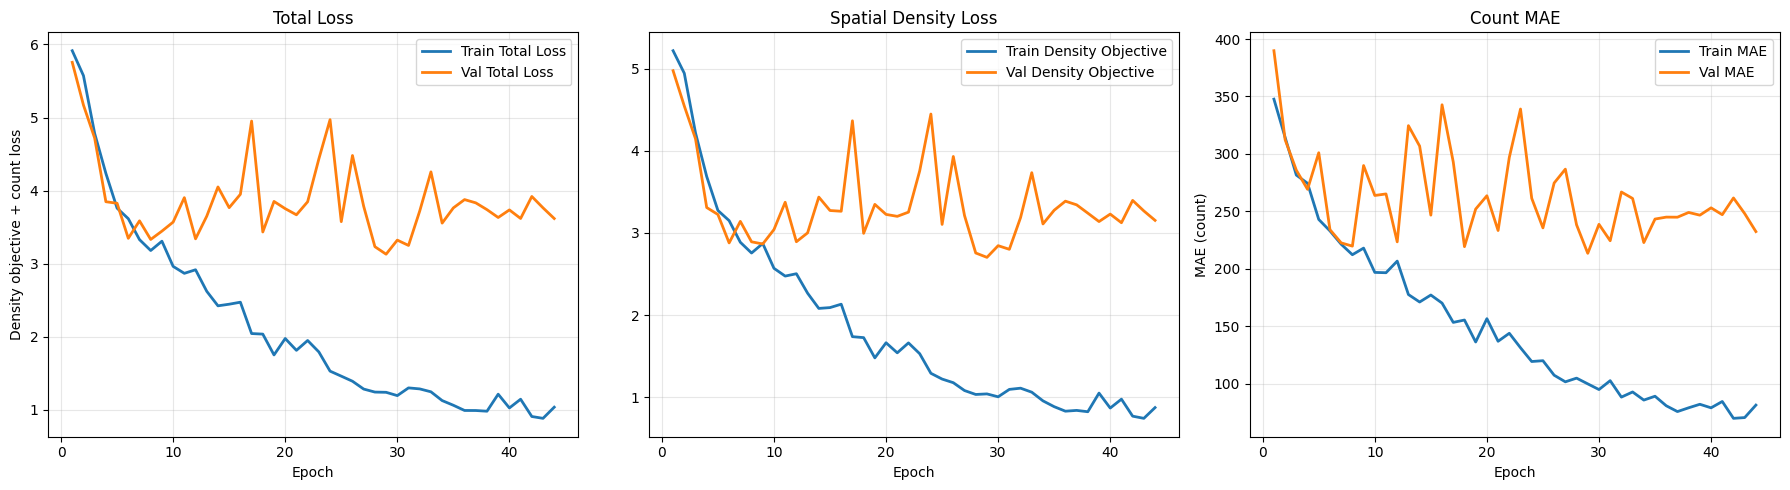

Saved -> /content/training_curves.png


In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train Total Loss", lw=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Total Loss",   lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Density objective + count loss")
axes[0].set_title("Total Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_density_loss"], label="Train Density Objective", lw=2)
axes[1].plot(epochs_ran, history["val_density_loss"],   label="Val Density Objective",   lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_title("Spatial Density Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history["train_mae"], label="Train MAE", lw=2)
axes[2].plot(epochs_ran, history["val_mae"],   label="Val MAE",   lw=2)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("MAE (count)")
axes[2].set_title("Count MAE"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150)
plt.show()
print("Saved -> /content/training_curves.png")


## 11 - Test-Set Evaluation  

Load the best checkpoint and compute count MAE / RMSE on the held-out test set.


In [ ]:
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}  (Val MAE={ckpt['val_mae']:.2f})")

model.eval()
all_pred, all_true = [], []

with torch.no_grad():
    for imgs, dens in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(DEVICE)
        preds = model(imgs)

        pred_count = preds.sum(dim=[1, 2, 3]).cpu().numpy()
        true_count = dens.sum(dim=[1, 2, 3]).numpy()

        all_pred.extend(pred_count.tolist())
        all_true.extend(true_count.tolist())

all_pred = np.array(all_pred)
all_true = np.array(all_true)

mae  = np.mean(np.abs(all_pred - all_true))
rmse = np.sqrt(np.mean((all_pred - all_true) ** 2))

print(f"\n{'='*40}")
print(f"  Test MAE  : {mae:.2f}")
print(f"  Test RMSE : {rmse:.2f}")
print(f"{'='*40}")


Loaded best checkpoint from epoch 29  (Val MAE=213.36)


Testing: 100%|██████████| 182/182 [00:52<00:00,  3.47it/s]


  Test MAE  : 144.21
  Test RMSE : 227.84


## 12 - Inference Visualisation

For each test sample we display:
1. Original image  
2. Ground-truth density map  
3. Predicted density map  
4. Actual count, predicted count, and absolute error


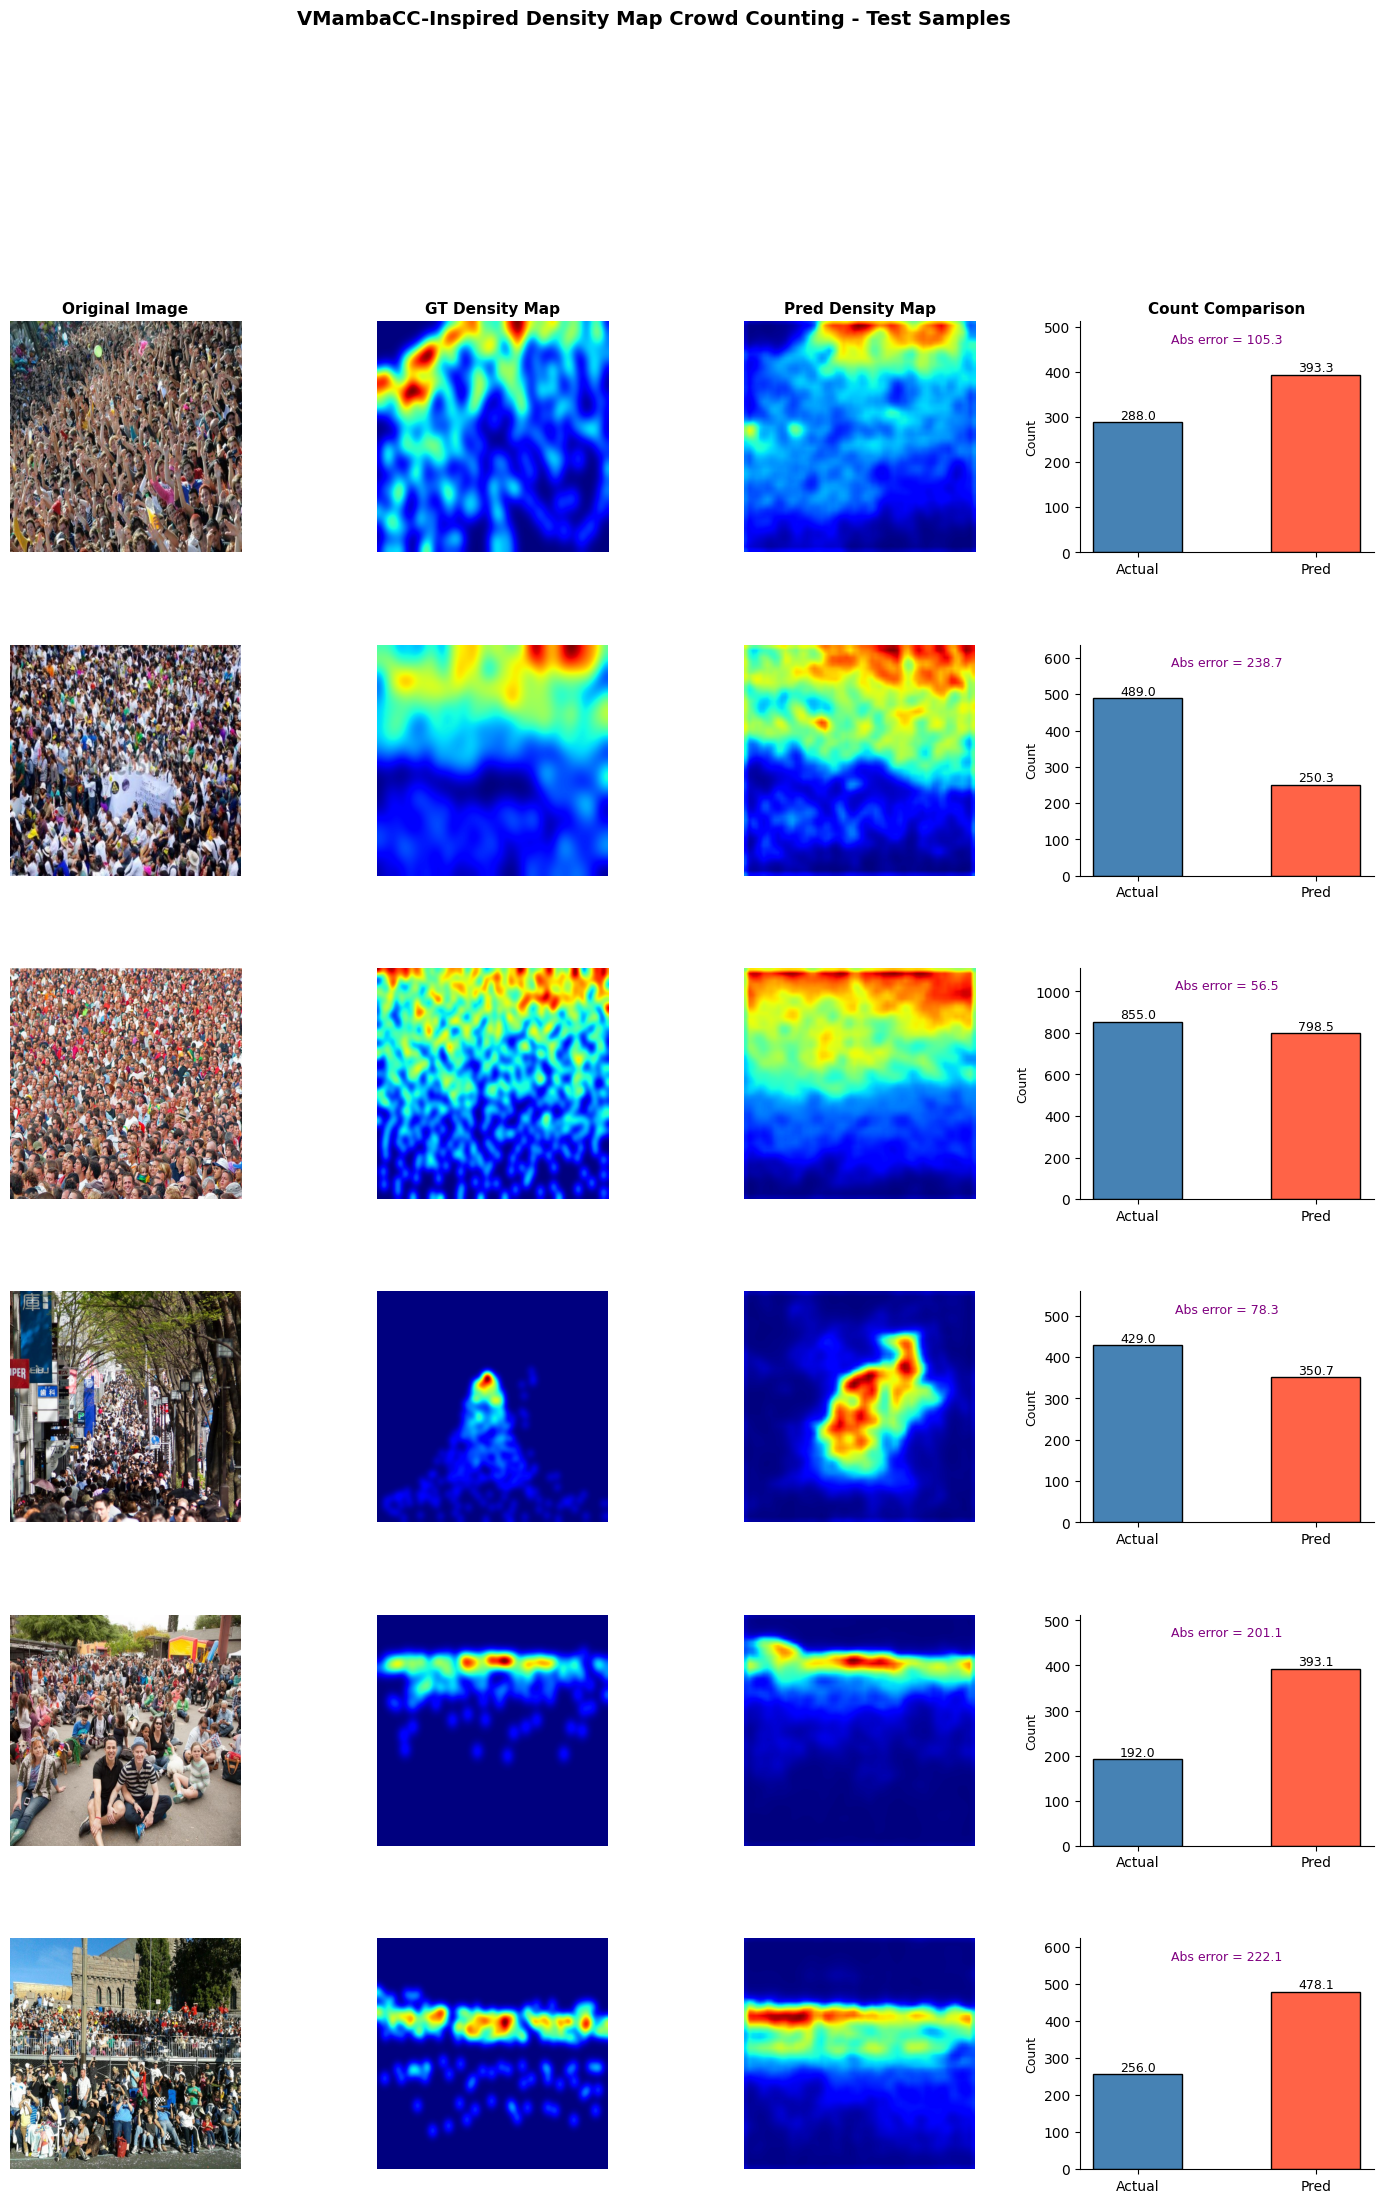

Saved -> /content/predictions.png


In [ ]:
def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = tensor.cpu() * std + mean
    img  = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


def visualise_predictions(model, dataset, n_samples=6, device=DEVICE):
    model.eval()
    n_samples = min(n_samples, len(dataset))
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    fig = plt.figure(figsize=(18, n_samples * 4))
    gs  = gridspec.GridSpec(n_samples, 4, figure=fig, hspace=0.4, wspace=0.25)

    col_titles = ["Original Image", "GT Density Map", "Pred Density Map", "Count Comparison"]

    for row, idx in enumerate(indices):
        img_t, den_t = dataset[idx]
        img_np  = denormalize(img_t)

        with torch.no_grad():
            pred_t = model(img_t.unsqueeze(0).to(device))

        den_np  = den_t.squeeze().numpy()
        pred_np = pred_t.squeeze().cpu().numpy()

        actual_count = den_np.sum()
        pred_count   = pred_np.sum()
        abs_error    = abs(pred_count - actual_count)

        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(img_np)
        ax.set_title(col_titles[0] if row == 0 else "", fontsize=11, fontweight="bold")
        ax.axis("off")

        ax = fig.add_subplot(gs[row, 1])
        ax.imshow(den_np, cmap="jet")
        ax.set_title(col_titles[1] if row == 0 else "", fontsize=11, fontweight="bold")
        ax.set_xlabel(f"Actual count: {actual_count:.1f}", fontsize=9)
        ax.axis("off")

        ax = fig.add_subplot(gs[row, 2])
        ax.imshow(pred_np, cmap="jet")
        ax.set_title(col_titles[2] if row == 0 else "", fontsize=11, fontweight="bold")
        ax.set_xlabel(f"Pred count: {pred_count:.1f}", fontsize=9)
        ax.axis("off")

        ax = fig.add_subplot(gs[row, 3])
        bars = ax.bar(["Actual", "Pred"], [actual_count, pred_count],
                      color=["steelblue", "tomato"], width=0.5, edgecolor="black")
        ax.set_title(col_titles[3] if row == 0 else "", fontsize=11, fontweight="bold")
        ax.set_ylabel("Count", fontsize=9)
        ax.set_ylim(0, max(actual_count, pred_count) * 1.3 + 1)
        for bar, val in zip(bars, [actual_count, pred_count]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5, f"{val:.1f}",
                    ha="center", va="bottom", fontsize=9)
        ax.text(0.5, 0.95, f"Abs error = {abs_error:.1f}", transform=ax.transAxes,
                ha="center", va="top", fontsize=9, color="purple")
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("VMambaCC-Inspired Density Map Crowd Counting - Test Samples",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.savefig("/content/predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved -> /content/predictions.png")


visualise_predictions(model, test_ds, n_samples=6)


## 13 - Summary

| Component | Paper reference | Implementation |
|-----------|----------------|----------------|
| VSS Block | Sec. 3.1, VMamba Cross-Scan | Depthwise-conv approximation, not official selective scan |
| MHF - CEM | Sec. 3.2.1, eq. (1-4) | Exact |
| MHF - MSEM | Sec. 3.2.2, eq. (5-6) | Exact (4 heads) |
| MHF - HCEM | Sec. 3.2.3, eq. (7-8) | Exact |
| HS2FPN | Sec. 3.3, eq. (9) | Top-down feature fusion with explicit channel projections |
| Model scale | wider training config | dims `(128, 256, 512)`, depths `(2, 3, 6)`, decoder output `128` |
| Density head | density map output (modification) | Conv head + Softplus + bilinear upsample |
| Count metrics | common crowd-counting metrics | MAE and RMSE from `sum(pred_map)` vs `sum(gt_map)` |

The main departure from the original VMambaCC paper is the **output representation**:  
the paper uses a point-based head (predicted points + confidence scores);  
this notebook replaces that with a **Gaussian-kernel density map** output, which  
is the more common approach and lets the model be evaluated with count MAE/RMSE.
